In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from data.utils.fsdd import FSDD
from src.data.dataloader import dataUtils, FSDDDataset
from src.utils.config import Config
from src.data.feat_aug import Augmentation, feature_extraction
from src.trainer.trainer import train_model
from src.model.mymodel import MLPMTLModel
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader
import torch

In [2]:
# audio_dir="C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\recordings\\"
# fsdd_tool = FSDD(audio_dir)

In [3]:
# spectr, label = fsdd_tool.get_spectrograms("C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\spectrotest\\")
# print(len(spectr[0]))

In [2]:
DataUtils = dataUtils()
waveform_data = DataUtils.load_data_waveform(Config.AUDIO_PATH)
print(len(waveform_data))

c:\Users\Ammar\miniconda3\envs\rfpp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3000


In [3]:
print(waveform_data)

[{'data_path': 'C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\recordings\\0_george_0.wav', 'y': array([-0.04229989, -0.04891741, -0.0376581 , ..., -0.00187708,
        0.00271878,  0.00249752], dtype=float32), 'sr': 22050, 'augmented': 0, 'speaker': 'george', 'digit': '0', 'sample_number': '0'}, {'data_path': 'C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\recordings\\0_george_1.wav', 'y': array([0.0009937 , 0.00099815, 0.00064652, ..., 0.00041118, 0.00051203,
       0.00028814], dtype=float32), 'sr': 22050, 'augmented': 0, 'speaker': 'george', 'digit': '0', 'sample_number': '1'}, {'data_path': 'C:\\Users\\Ammar\\OneDrive\\Dokumen\\NextCloud\\My Documents\\Kuylah S2\\SEM 2\\RFPP\\RFPP_Task\\Last Project\\pseudo MTL\\data\\recordings\\0_george_10.wav', 'y': array([-0.00656158, -0.014037  , -0.01716694, ..., -0.0027096 ,
    

In [4]:
aug = Augmentation()

audio_augmentations = [
    lambda y, sr: aug.add_gaussian_noise(y, noise_factor=0.005),
    lambda y, sr: aug.time_shift(y, time_shift_max=0.2),
    lambda y, sr: aug.pitch_shift(y, sr, pitch_steps=[-1, 1]),
    lambda y, sr: aug.time_stretch(y, rate=1.1),
    lambda y, sr: aug.volume_scale(y, scale_range=(0.7, 1.3)),
]

augmented_waveform_data = aug.random_waveform_augmentation(audio_augmentations, waveform_data)

1517 data diaugmentasi


In [5]:
waveform_data.extend(augmented_waveform_data)
mfcc_data = feature_extraction(waveform_data)

In [6]:
print(mfcc_data)

[{'augmented': 0, 'speaker': 'george', 'digit': '0', 'sample_number': '0', 'mfcc_feature': array([ 6.07118236e-05,  8.88652578e-02,  3.16208839e-01, -2.87280589e-01,
        6.04717548e-02,  8.37253854e-02,  1.39007426e+03,  3.91326452e+02,
        1.11597213e+03,  2.21769729e+02,  2.62539438e+03,  7.35832387e+02,
       -1.55368347e+02,  1.15919174e+02, -4.18410568e+01,  4.22475128e+01,
        3.20735550e+01, -2.55104294e+01,  3.35551834e+00, -7.68906736e+00,
       -2.27011337e+01,  2.13735604e+00, -1.44706774e+01, -1.69169807e+01,
        7.37480068e+00, -3.46834683e+00, -6.50074244e+00,  3.88444042e+00,
       -1.97251248e+00,  1.12847853e+00,  1.48245156e+00, -4.86364460e+00,
        1.79738579e+01,  1.62294731e+01,  1.56230984e+01,  1.84653606e+01,
        1.37399178e+01,  9.47696495e+00,  5.13838673e+00,  6.43896627e+00,
        5.85224581e+00,  7.38846397e+00,  5.09878874e+00,  5.25741768e+00,
        3.08128905e+00,  6.01232719e+00,  5.96149921e+00,  3.02601218e+00,
        4

In [7]:
mfcc_df = pd.DataFrame(mfcc_data)
mfcc_df.head()

,augmented,speaker,digit,sample_number,mfcc_feature
0,0,george,0,0,"[6.071182360756211e-05, 0.0888652577996254, 0...."
1,0,george,0,1,"[-2.2823935069027357e-05, 0.05002695694565773,..."
2,0,george,0,10,"[-2.9235707188490778e-05, 0.04465978965163231,..."
3,0,george,0,11,"[-2.0361474525998347e-05, 0.047294557094573975..."
4,0,george,0,12,"[-1.4424660548684187e-05, 0.04648785665631294,..."


In [8]:
cols_to_fix = ['digit', 'sample_number'] 

mfcc_df[cols_to_fix] = mfcc_df[cols_to_fix].astype(int)

mfcc_df = mfcc_df.sort_values(
    by=['speaker', 'digit', 'sample_number'], 
    ascending=True
).reset_index(drop=True)

# mfcc_expanded = pd.DataFrame(
#     mfcc_df["mfcc_feature"].tolist(),
#     columns=[f"mfcc_feature_{i}" for i in range(len(mfcc_df["mfcc_feature"].iloc[0]))]
# )

# mfcc_df = pd.concat([mfcc_df.drop(columns=["mfcc_feature"]), mfcc_expanded], axis=1)
mfcc_df.head()

,augmented,speaker,digit,sample_number,mfcc_feature
0,0,george,0,0,"[6.071182360756211e-05, 0.0888652577996254, 0...."
1,1,george,0,0,"[3.775641744141467e-05, 0.08906041085720062, 0..."
2,0,george,0,1,"[-2.2823935069027357e-05, 0.05002695694565773,..."
3,0,george,0,2,"[-2.652477633091621e-05, 0.07252717018127441, ..."
4,0,george,0,3,"[-2.0533616407192312e-05, 0.07549626380205154,..."


In [9]:
train_data, test_data, val_data = DataUtils.data_split(mfcc_df)

In [10]:
le = LabelEncoder()
train_data['speaker_id'] = le.fit_transform(train_data['speaker'])
test_data['speaker_id'] = le.transform(test_data['speaker'])
val_data['speaker_id'] = le.transform(val_data['speaker'])

In [11]:
scaled = dataUtils.scale_features(train_data, val_data, test_data)

X_train = scaled['train']
X_val   = scaled['val']
X_test  = scaled['test']
scaler  = scaled['scaler']  # simpan untuk inference nanti

In [12]:
# mfcc_augmentations = [
#     lambda m: aug.time_masking(m, max_mask_t=5),
#     lambda m: aug.freq_masking(m, max_mask_f=2)
# ]

train_dataset = FSDDDataset(
    df=train_data,
    scaled_data=X_train,
    mfcc_transform=None
)

test_dataset = FSDDDataset(
    df=test_data, 
    scaled_data=X_test,
    mfcc_transform=None
)

val_dataset = FSDDDataset(
    df=val_data, 
    scaled_data=X_val,
    mfcc_transform=None
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [13]:
model = MLPMTLModel(input_size=52, num_classes_task1=10, num_classes_task2=6)
history = train_model(
    model, train_loader, val_loader,
    epochs=100, lr=0.00025, val_step=5,
    patience=10, save_path="best_model.pt"
)

c:\Users\Ammar\miniconda3\envs\rfpp\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training started on device: cuda
Epoch [1/100] - total_loss=2.6384 - l1=2.2773 - l2=1.8055
Epoch [2/100] - total_loss=2.4913 - l1=2.1560 - l2=1.6765
Epoch [3/100] - total_loss=2.3316 - l1=2.0195 - l2=1.5601
Epoch [4/100] - total_loss=2.1624 - l1=1.8736 - l2=1.4443
Epoch [5/100] - total_loss=1.9825 - l1=1.7153 - l2=1.3360
  → Val Loss: 1.8856 | Digit  Acc: 0.6840 F1: 0.6735 | Speaker Acc: 0.7271 F1: 0.7180
 ← best model saved! (digit_acc=0.6840)
Epoch [6/100] - total_loss=1.8035 - l1=1.5574 - l2=1.2303
Epoch [7/100] - total_loss=1.6316 - l1=1.4056 - l2=1.1300
Epoch [8/100] - total_loss=1.4709 - l1=1.2622 - l2=1.0437
Epoch [9/100] - total_loss=1.3338 - l1=1.1416 - l2=0.9611
Epoch [10/100] - total_loss=1.2218 - l1=1.0437 - l2=0.8907
  → Val Loss: 1.1284 | Digit  Acc: 0.8221 F1: 0.8221 | Speaker Acc: 0.8608 F1: 0.8597
 ← best model saved! (digit_acc=0.8221)
Epoch [11/100] - total_loss=1.1219 - l1=0.9544 - l2=0.8373
Epoch [12/100] - total_loss=1.0467 - l1=0.8887 - l2=0.7898
Epoch [13/100] -

C:\Users\Ammar\AppData\Local\Temp\ipykernel_28780\3241159553.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


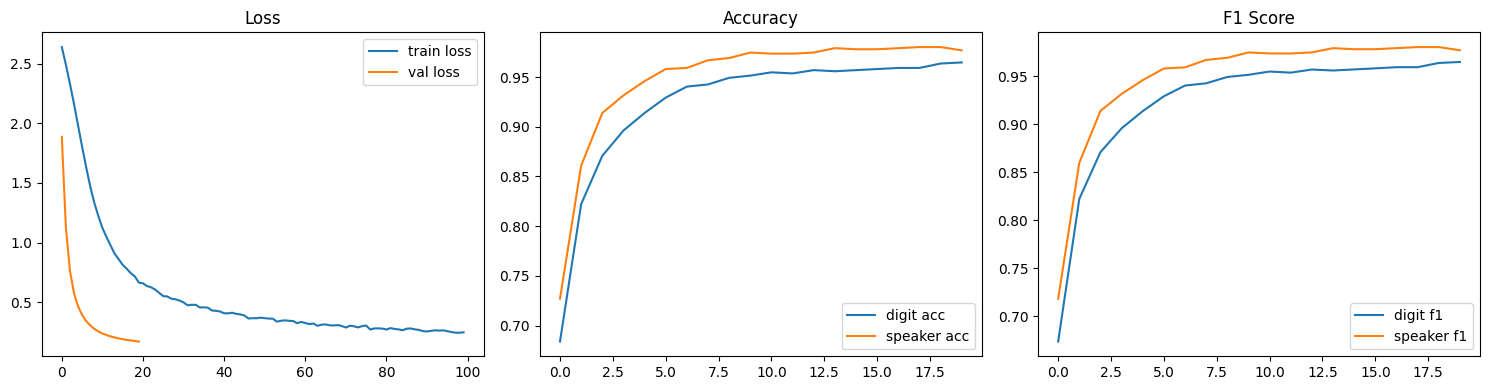

In [14]:

# Load model terbaik setelah training
model.load_state_dict(torch.load("best_model.pt"))

# Plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train loss")
axes[0].plot(history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["digit_acc"], label="digit acc")
axes[1].plot(history["speaker_acc"], label="speaker acc")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(history["digit_f1"], label="digit f1")
axes[2].plot(history["speaker_f1"], label="speaker f1")
axes[2].set_title("F1 Score"); axes[2].legend()

plt.tight_layout()
plt.show()